In [109]:
import pandas as pd
import numpy as np

df=pd.read_csv("/content/mental_health_chatbot_300_rows.csv")
df.head()

,question,answer
0,How are you feeling today?,I am here to listen without judgment.
1,I feel sad.,I'm sorry you're feeling sad. Want to share more?
2,I feel anxious.,Let's slow down. What is making you anxious?
3,I feel scared.,Your feelings matter. Are you safe right now?
4,I feel lonely.,Loneliness can hurt. You don't have to face it...


In [110]:
df["question"]=df.question.str.lower()
df["answer"]=df.answer.str.lower()
df.head()

,question,answer
0,how are you feeling today?,i am here to listen without judgment.
1,i feel sad.,i'm sorry you're feeling sad. want to share more?
2,i feel anxious.,let's slow down. what is making you anxious?
3,i feel scared.,your feelings matter. are you safe right now?
4,i feel lonely.,loneliness can hurt. you don't have to face it...


In [111]:
df["question"]=df.question.apply(lambda x: "<BOS>"+x+"<EOS>")
df["answer"]=df.answer.apply(lambda x: "<BOS>"+x+"<EOS>")
df.head()

,question,answer
0,<BOS>how are you feeling today?<EOS>,<BOS>i am here to listen without judgment.<EOS>
1,<BOS>i feel sad.<EOS>,<BOS>i'm sorry you're feeling sad. want to sha...
2,<BOS>i feel anxious.<EOS>,<BOS>let's slow down. what is making you anxio...
3,<BOS>i feel scared.<EOS>,<BOS>your feelings matter. are you safe right ...
4,<BOS>i feel lonely.<EOS>,<BOS>loneliness can hurt. you don't have to fa...


In [112]:
import re
df["question_tokens"] = df["question"].apply(
    lambda x: re.findall(r"<BOS>|<EOS>|\w+|[^\w\s]", x)
)

df["answer_tokens"] = df["answer"].apply(
    lambda x: re.findall(r"<BOS>|<EOS>|\w+|[^\w\s]", x)
)

In [113]:
df.head()

,question,answer,question_tokens,answer_tokens
0,<BOS>how are you feeling today?<EOS>,<BOS>i am here to listen without judgment.<EOS>,"[<BOS>, how, are, you, feeling, today, ?, <EOS>]","[<BOS>, i, am, here, to, listen, without, judg..."
1,<BOS>i feel sad.<EOS>,<BOS>i'm sorry you're feeling sad. want to sha...,"[<BOS>, i, feel, sad, ., <EOS>]","[<BOS>, i, ', m, sorry, you, ', re, feeling, s..."
2,<BOS>i feel anxious.<EOS>,<BOS>let's slow down. what is making you anxio...,"[<BOS>, i, feel, anxious, ., <EOS>]","[<BOS>, let, ', s, slow, down, ., what, is, ma..."
3,<BOS>i feel scared.<EOS>,<BOS>your feelings matter. are you safe right ...,"[<BOS>, i, feel, scared, ., <EOS>]","[<BOS>, your, feelings, matter, ., are, you, s..."
4,<BOS>i feel lonely.<EOS>,<BOS>loneliness can hurt. you don't have to fa...,"[<BOS>, i, feel, lonely, ., <EOS>]","[<BOS>, loneliness, can, hurt, ., you, don, ',..."


In [114]:
all_tokens = []

for tokens in df["question_tokens"]:
    all_tokens.extend(tokens)

for tokens in df["answer_tokens"]:
    all_tokens.extend(tokens)

In [115]:
unique_tokens = sorted(set(all_tokens))

In [116]:
unique_tokens

["'",
 ',',
 '-',
 '.',
 ':',
 ';',
 '<BOS>',
 '<EOS>',
 '?',
 'a',
 'ability',
 'about',
 'abuse',
 'abuser',
 'accept',
 'achievable',
 'acknowledge',
 'action',
 'actions',
 'active',
 'adapt',
 'addresses',
 'advice',
 'advocate',
 'advocates',
 'affect',
 'affecting',
 'afford',
 'afraid',
 'after',
 'afterward',
 'again',
 'alert',
 'all',
 'allow',
 'allowed',
 'alone',
 'also',
 'always',
 'am',
 'an',
 'and',
 'anger',
 'angry',
 'animals',
 'anonymous',
 'another',
 'answers',
 'anxiety',
 'anxious',
 'anymore',
 'anyone',
 'apologizing',
 'appeasing',
 'appetite',
 'appropriate',
 'are',
 'arise',
 'around',
 'as',
 'ashamed',
 'ask',
 'asking',
 'assess',
 'assistance',
 'assuming',
 'at',
 'attack',
 'attacked',
 'attention',
 'attentively',
 'authorities',
 'authority',
 'automatic',
 'available',
 'avoid',
 'avoidance',
 'away',
 'back',
 'bad',
 'basic',
 'be',
 'become',
 'bed',
 'before',
 'begin',
 'behalf',
 'behaviors',
 'being',
 'believe',
 'benefit',
 'benefits'

In [117]:
unique_tokens.extend(["<PAD>", "<UNK>"])
unique_tokens=sorted(unique_tokens)

In [118]:
ntw={n:w for n,w in enumerate(unique_tokens)}
wtn={w:n for n,w in enumerate(unique_tokens)}
wtn

{"'": 0,
 ',': 1,
 '-': 2,
 '.': 3,
 ':': 4,
 ';': 5,
 '<BOS>': 6,
 '<EOS>': 7,
 '<PAD>': 8,
 '<UNK>': 9,
 '?': 10,
 'a': 11,
 'ability': 12,
 'about': 13,
 'abuse': 14,
 'abuser': 15,
 'accept': 16,
 'achievable': 17,
 'acknowledge': 18,
 'action': 19,
 'actions': 20,
 'active': 21,
 'adapt': 22,
 'addresses': 23,
 'advice': 24,
 'advocate': 25,
 'advocates': 26,
 'affect': 27,
 'affecting': 28,
 'afford': 29,
 'afraid': 30,
 'after': 31,
 'afterward': 32,
 'again': 33,
 'alert': 34,
 'all': 35,
 'allow': 36,
 'allowed': 37,
 'alone': 38,
 'also': 39,
 'always': 40,
 'am': 41,
 'an': 42,
 'and': 43,
 'anger': 44,
 'angry': 45,
 'animals': 46,
 'anonymous': 47,
 'another': 48,
 'answers': 49,
 'anxiety': 50,
 'anxious': 51,
 'anymore': 52,
 'anyone': 53,
 'apologizing': 54,
 'appeasing': 55,
 'appetite': 56,
 'appropriate': 57,
 'are': 58,
 'arise': 59,
 'around': 60,
 'as': 61,
 'ashamed': 62,
 'ask': 63,
 'asking': 64,
 'assess': 65,
 'assistance': 66,
 'assuming': 67,
 'at': 68,
 'a

In [119]:
maxq = max(df["question_tokens"].apply(len))
maxa = max(df["answer_tokens"].apply(len))

df["question_ids"] = df["question_tokens"].apply(
    lambda x: [wtn[token] for token in x]
)

df["answer_ids"] = df["answer_tokens"].apply(
    lambda x: [wtn[token] for token in x]
)

df

,question,answer,question_tokens,answer_tokens,question_ids,answer_ids
0,<BOS>how are you feeling today?<EOS>,<BOS>i am here to listen without judgment.<EOS>,"[<BOS>, how, are, you, feeling, today, ?, <EOS>]","[<BOS>, i, am, here, to, listen, without, judg...","[6, 370, 58, 899, 290, 824, 10, 7]","[6, 378, 41, 364, 823, 437, 888, 421, 3, 7]"
1,<BOS>i feel sad.<EOS>,<BOS>i'm sorry you're feeling sad. want to sha...,"[<BOS>, i, feel, sad, ., <EOS>]","[<BOS>, i, ', m, sorry, you, ', re, feeling, s...","[6, 378, 289, 676, 3, 7]","[6, 378, 0, 450, 737, 899, 0, 609, 290, 676, 3..."
2,<BOS>i feel anxious.<EOS>,<BOS>let's slow down. what is making you anxio...,"[<BOS>, i, feel, anxious, ., <EOS>]","[<BOS>, let, ', s, slow, down, ., what, is, ma...","[6, 378, 289, 51, 3, 7]","[6, 434, 0, 675, 727, 234, 3, 876, 412, 455, 8..."
3,<BOS>i feel scared.<EOS>,<BOS>your feelings matter. are you safe right ...,"[<BOS>, i, feel, scared, ., <EOS>]","[<BOS>, your, feelings, matter, ., are, you, s...","[6, 378, 289, 685, 3, 7]","[6, 900, 291, 460, 3, 58, 899, 678, 668, 514, ..."
4,<BOS>i feel lonely.<EOS>,<BOS>loneliness can hurt. you don't have to fa...,"[<BOS>, i, feel, lonely, ., <EOS>]","[<BOS>, loneliness, can, hurt, ., you, don, ',...","[6, 378, 289, 443, 3, 7]","[6, 442, 119, 374, 3, 899, 232, 0, 781, 351, 8..."
...,...,...,...,...,...,...
295,<BOS>how do i ask for space?<EOS>,<BOS>say: i need some time alone right now.<EOS>,"[<BOS>, how, do, i, ask, for, space, ?, <EOS>]","[<BOS>, say, :, i, need, some, time, alone, ri...","[6, 370, 227, 378, 63, 303, 740, 10, 7]","[6, 683, 4, 378, 499, 733, 818, 38, 668, 514, ..."
296,<BOS>i feel pressure to forgive.<EOS>,<BOS>healing does not require immediate forgiv...,"[<BOS>, i, feel, pressure, to, forgive, ., <EOS>]","[<BOS>, healing, does, not, require, immediate...","[6, 378, 289, 580, 823, 305, 3, 7]","[6, 354, 231, 510, 648, 384, 306, 3, 7]"
297,<BOS>i cannot forgive them.<EOS>,<BOS>you are not required to force forgiveness...,"[<BOS>, i, cannot, forgive, them, ., <EOS>]","[<BOS>, you, are, not, required, to, force, fo...","[6, 378, 120, 305, 799, 3, 7]","[6, 899, 58, 510, 649, 823, 304, 306, 3, 7]"
298,<BOS>i want my confidence back.<EOS>,<BOS>confidence can rebuild through small succ...,"[<BOS>, i, want, my, confidence, back, ., <EOS>]","[<BOS>, confidence, can, rebuild, through, sma...","[6, 378, 866, 492, 158, 80, 3, 7]","[6, 158, 119, 619, 817, 729, 764, 20, 3, 7]"


In [120]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

question_padded = pad_sequences(
    df["question_ids"],
    maxlen=maxq,
    padding="post",
    value=wtn["<PAD>"]
)

answer_padded = pad_sequences(
    df["answer_ids"],
    maxlen=maxa,
    padding="post",
    value=wtn["<PAD>"]
)


In [121]:
question_padded[0]

array([  6, 370,  58, 899, 290, 824,  10,   7,   8,   8,   8], dtype=int32)

In [122]:
import torch
import torch.nn as nn

vocab_size = len(unique_tokens)
d_model = 128

embedding = nn.Embedding(
    num_embeddings=vocab_size,
    embedding_dim=d_model
)
embedding

Embedding(903, 128)

In [123]:
xq=torch.tensor(question_padded)
xa=torch.tensor(answer_padded)
embedded_q=embedding(xq)
embedded_a=embedding(xa)

print(embedded_q.shape,embedded_a.shape)

torch.Size([300, 11, 128]) torch.Size([300, 17, 128])


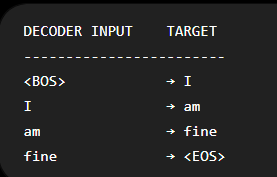

In [124]:
question_embedded = embedded_q.detach().numpy()
#Take everything except the last token.
decoder_input_data = embedded_a[:, :-1, :].detach().numpy()
#Take everything except the first token.
target = answer_padded[:, 1:]

print(question_embedded.shape)
print(decoder_input_data.shape)
print(target.shape)

(300, 11, 128)
(300, 16, 128)
(300, 16)


In [125]:
import tensorflow as tf
from tensorflow.keras import layers, Model

#encoder
encoder_input = layers.Input(shape=(11, 128))

encoder_lstm = layers.LSTM(
    256,
    return_state=True
)

encoder_output, encoder_h, encoder_c = encoder_lstm(encoder_input)

#decoder
decoder_input = layers.Input(
    shape=(16, 128),
    name="decoder_input"
)

decoder_lstm = layers.LSTM(
    256,
    return_sequences=True,
    return_state=True,
    name="decoder_lstm"
)

decoder_output, _, _ = decoder_lstm(
    decoder_input,
    initial_state=[encoder_h, encoder_c]
)



In [126]:
vocab_size = len(unique_tokens)

output_layer = layers.Dense(
    vocab_size,
    activation="softmax"
)

output = output_layer(decoder_output)
model = Model(
    inputs=[encoder_input, decoder_input],
    outputs=output
)

In [127]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 11, 128)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 16, 128)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ [(None, 256),     │    394,240 │ input_layer_4[0]… │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 16, 256), │    394,240 │ decoder_input[0]… │
│                     │ (None, 256),      │            │ lstm_4[0][1],     │
│                     │ (None, 256)]      │            │ lstm_4[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 16, 903)   │    232,071 │ decoder_lstm[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,020,551 (3.89 MB)

 Trainable params: 1,020,551 (3.89 MB)

 Non-trainable params: 0 (0.00 B)

In [128]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["sparse_categorical_accuracy"]
)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    [question_embedded, decoder_input_data],
    target,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 4.9855 - sparse_categorical_accuracy: 0.3193 - val_loss: 3.6828 - val_sparse_categorical_accuracy: 0.3698
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 3.4316 - sparse_categorical_accuracy: 0.4451 - val_loss: 3.4675 - val_sparse_categorical_accuracy: 0.4844
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 3.1998 - sparse_categorical_accuracy: 0.4807 - val_loss: 3.4448 - val_sparse_categorical_accuracy: 0.4990
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 3.0710 - sparse_categorical_accuracy: 0.4885 - val_loss: 3.4365 - val_sparse_categorical_accuracy: 0.5010
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2.9739 - sparse_categorical_accuracy: 0.4917 - val_loss: 3.4387 - val_sparse_categorical_accuracy: 0.5156
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2.8763 - sparse_categorical_accuracy: 0.5026 - val_loss: 3.4269 - val_sparse_categorical_accuracy: 0.5135
Epoc

In [129]:
decoder_input.shape

(None, 16, 128)

In [130]:
import numpy as np

# Encoder model
encoder_model = Model(
    encoder_input,
    [encoder_h, encoder_c]
)

# Decoder inputs
decoder_token_input = layers.Input(shape=(1, 128))

decoder_h_input = layers.Input(shape=(256,))
decoder_c_input = layers.Input(shape=(256,))

decoder_output, decoder_h, decoder_c = decoder_lstm(
    decoder_token_input,
    initial_state=[decoder_h_input, decoder_c_input]
)

decoder_output = output_layer(decoder_output)

decoder_model = Model(
    [decoder_token_input, decoder_h_input, decoder_c_input],
    [decoder_output, decoder_h, decoder_c]
)

In [131]:
def chatbot(question):

    # Add BOS and EOS
    question = "<BOS>" + question.lower() + "<EOS>"

    # Tokenize
    tokens = re.findall(
        r"<BOS>|<EOS>|\w+|[^\w\s]",
        question
    )

    # Convert words to IDs
    ids = [wtn.get(token, wtn["<UNK>"]) for token in tokens]

    # Pad
    ids = pad_sequences(
        [ids],
        maxlen=maxq,
        padding="post",
        value=wtn["<PAD>"]
    )

    # Convert to embedding
    ids = torch.tensor(ids)

    question_embedding = embedding(ids)

    question_embedding = question_embedding.detach().numpy()

    # Encoder
    h, c = encoder_model.predict(
        question_embedding,
        verbose=0
    )

    # Start decoder with BOS
    current_token = wtn["<BOS>"]

    answer = []

    for _ in range(maxa):

        # Get embedding of current word
        token_tensor = torch.tensor([[current_token]])

        token_embedding = embedding(token_tensor)

        token_embedding = token_embedding.detach().numpy()

        # Decoder prediction
        prediction, h, c = decoder_model.predict(
            [token_embedding, h, c],
            verbose=0
        )

        # Pick highest probability word
        next_token = np.argmax(prediction[0, 0])

        # Stop at EOS
        if next_token == wtn["<EOS>"]:
            break

        # Ignore PAD
        if next_token != wtn["<PAD>"]:
            answer.append(ntw[next_token])

        current_token = next_token

    return " ".join(answer)

In [132]:
print(chatbot("I feel very sad"))

you can be . seek you safe now ?
